# Octree Init (L4) — Architecture Shootout

This notebook tests candidate architectures for **Model A (`octree_init`)**, the root-level
model that generates the initial coarse 32³ WorldSection from conditioning alone (no parent context).

## Candidates

| ID | Architecture | Channels | Rationale |
|----|-------------|----------|-----------|
| A1 | Full 3D U-Net | [24,48,96] | Baseline — all-3D from the start |
| A2 | Full 3D U-Net (wider) | [32,64,128] | More capacity for the same architecture |
| A3 | 2D conv encoder → 3D decoder | [24,48,96] | L4 conditioning is fundamentally 2D |
| A4 | Hybrid 2D→3D with attention bottleneck | [24,48,96] | Attention for global context at 8³ |

## Test Matrix
Each candidate × {with_occ_head, without_occ_head} = **8 configurations**

## Metrics
- Block accuracy (overall, air, non-air)
- Top-5 accuracy
- Occupancy F1 (precision/recall) when occ head is enabled
- Inference latency (CPU)
- Parameter count

In [21]:
from __future__ import annotations

import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

import octree_shootout_utils as shootout_utils

importlib.reload(shootout_utils)

from octree_shootout_utils import (
    ARTIFACT_DIR,
    DATA_DIR,
    DEVICE,
    NUM_BIOMES,
    NUM_BLOCK_CLASSES,
    NUM_Y_POSITIONS,
    ROOT,
    SEED,
    SPATIAL,
    benchmark_latency as shared_benchmark_latency,
    bitmask_to_binary,
    compute_block_log_priors,
    compute_block_metrics,
    compute_occ_metrics,
    cross_entropy_loss,
    describe_split,
    init_block_head_bias,
    load_pair_cache_subset,
    make_loader,
    maybe_load_class_weights,
    occupancy_loss,
    seed_everything,
)

seed_everything(SEED)
CLASS_WEIGHTS = maybe_load_class_weights(DATA_DIR)

print('ROOT =', ROOT)
print('DATA_DIR =', DATA_DIR)
print('DEVICE =', DEVICE)
print('CLASS_WEIGHTS =', None if CLASS_WEIGHTS is None else tuple(CLASS_WEIGHTS.shape))

ROOT = c:\Users\JeffHall\git\MC\VoxelTree
DATA_DIR = c:\Users\JeffHall\git\MC\VoxelTree\data\voxy_octree
DEVICE = cpu
CLASS_WEIGHTS = None


## Data Loading

Load real L4 data from the production pair caches. Each sample includes:
- `labels32`: target 32³ block IDs
- `heightmap32`: 5-channel height features (surface, ocean_floor, slope_x, slope_z, curvature)
- `biome32`: biome indices per `(x, z)` column
- `y_position`: integer Y section coordinate `(0–23)`
- `non_empty_children`: 8-bit occupancy mask

L4 has **no parent context** — conditioning comes only from world metadata.

If the pair caches are missing, the notebook now fails immediately instead of falling back to synthetic data.

In [22]:
AIR = 0
STONE = 1
DIRT = 3
GRASS_BLOCK = 9
SAND = 66
WATER = 34
DEEPSLATE = 899


def load_init_data() -> tuple[dict, dict]:
    train_data = load_pair_cache_subset('train', levels=[4], include_occ=True)
    val_data = load_pair_cache_subset('val', levels=[4], include_occ=True)
    if train_data is None or val_data is None:
        raise FileNotFoundError(
            'Missing required pair caches for init shootout. Expected '
            'data/voxy_octree/train_octree_pairs.npz and val_octree_pairs.npz.'
        )
    print('Loaded production pair caches for L4 init shootout.')
    return train_data, val_data


train_data, val_data = load_init_data()
BLOCK_LOG_PRIORS = compute_block_log_priors(
    train_data['labels32'],
    num_classes=NUM_BLOCK_CLASSES,
)

describe_split('train', train_data)
describe_split('val', val_data)

Loaded production pair caches for L4 init shootout.
Computed block priors: total_voxels=1,114,112 air=93.06% seen=74/1104
train:
  labels32: shape=(34, 32, 32, 32) dtype=int32
  heightmap32: shape=(34, 5, 32, 32) dtype=float32
  biome32: shape=(34, 32, 32) dtype=int32
  y_position: shape=(34,) dtype=int64
  non_empty_children: shape=(34,) dtype=uint8
val:
  labels32: shape=(3, 32, 32, 32) dtype=int32
  heightmap32: shape=(3, 5, 32, 32) dtype=float32
  biome32: shape=(3, 32, 32) dtype=int32
  y_position: shape=(3,) dtype=int64
  non_empty_children: shape=(3,) dtype=uint8


In [23]:
# ── Data sanity checks ─────────────────────────────────────────────
labels = train_data['labels32']
print(f'Air fraction: {(labels == AIR).mean():.3f}')
print(f'Non-empty children mean bits: {np.mean([bin(x).count("1") for x in train_data["non_empty_children"]]):.1f}')
unique_blocks = np.unique(labels)
print(f'Unique block types: {len(unique_blocks)} → {unique_blocks[:20]}')

Air fraction: 0.931
Non-empty children mean bits: 3.1
Unique block types: 74 → [  0   6   7  20  23  68  69 147 148 152 163 170 171 195 198 201 207 221
 275 281]


In [24]:
BATCH_SIZE = 8
train_loader = make_loader(train_data, batch_size=BATCH_SIZE, shuffle=True, include_occ=True)
val_loader = make_loader(val_data, batch_size=BATCH_SIZE, shuffle=False, include_occ=True)

batch = next(iter(train_loader))
for k, v in batch.items():
    print(f'{k}: {tuple(v.shape)} {v.dtype}')

labels32: (8, 32, 32, 32) torch.int64
heightmap32: (8, 5, 32, 32) torch.float32
biome32: (8, 32, 32) torch.int64
y_position: (8,) torch.int64
non_empty_children: (8,) torch.int64


## Building Blocks

Shared components for all init model candidates.

In [25]:
class Conv3dBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class DoubleConv3d(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(Conv3dBlock(in_ch, out_ch), Conv3dBlock(out_ch, out_ch))
    def forward(self, x): return self.block(x)


class Conv2dBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class DoubleConv2d(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(Conv2dBlock(in_ch, out_ch), Conv2dBlock(out_ch, out_ch))
    def forward(self, x): return self.block(x)


class OccupancyHead(nn.Module):
    """Spatial octant pooling → shared MLP → 8 logits."""
    def __init__(self, in_ch: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_ch, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        bsz, channels = x.shape[:2]
        pooled = x.reshape(bsz, channels, 2, 4, 2, 4, 2, 4).mean(dim=(3, 5, 7))
        pooled = pooled.reshape(bsz, channels, 8).permute(0, 2, 1)
        return self.mlp(pooled).squeeze(-1)


class ConditioningEncoder(nn.Module):
    """Encode heightmap(5,32,32) + biome(32,32) + y_pos → (B, out_ch, 32, 32, 32) volume."""
    def __init__(self, out_ch: int, biome_dim: int = 8, y_dim: int = 8):
        super().__init__()
        self.biome_emb = nn.Embedding(NUM_BIOMES, biome_dim)
        self.y_emb = nn.Embedding(NUM_Y_POSITIONS, y_dim)
        self.conv2d = nn.Sequential(
            nn.Conv2d(5 + biome_dim, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
        self.y_proj = nn.Linear(y_dim, out_ch)

    def forward(self, hm, biome, y_pos):
        bsz = hm.shape[0]
        biome_feat = self.biome_emb(biome.clamp(0, NUM_BIOMES - 1)).permute(0, 3, 1, 2)
        cond_2d = self.conv2d(torch.cat([hm, biome_feat], dim=1))
        cond_3d = cond_2d.unsqueeze(2).expand(-1, -1, SPATIAL, -1, -1)
        y_feat = self.y_proj(self.y_emb(y_pos.clamp(0, NUM_Y_POSITIONS - 1))).view(bsz, -1, 1, 1, 1)
        return cond_3d + y_feat


print('Building blocks defined.')

Building blocks defined.


## Candidate A1/A2: Full 3D U-Net (`full_3d_unet`)

Standard approach: encode all conditioning into a 3D volume, then process with
a 3-level 3D U-Net (32³→16³→8³). A1 uses channels [24,48,96], A2 uses [32,64,128].

In [26]:
class Full3DUNet(nn.Module):
    """Standard 3D U-Net initialized from conditioning volume.

    A1 instantiation: c0=24, c1=48, c2=96  (~400K params)
    A2 instantiation: c0=32, c1=64, c2=128 (~800K params)
    """

    def __init__(self, c0: int = 24, c1: int = 48, c2: int = 96,
                 num_classes: int = NUM_BLOCK_CLASSES, use_occ: bool = True):
        super().__init__()
        self.cond = ConditioningEncoder(out_ch=c0)

        # Encoder
        self.enc1 = DoubleConv3d(c0, c0)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = DoubleConv3d(c0, c1)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = DoubleConv3d(c1, c2)

        # Decoder
        self.up2 = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False)
        self.dec2 = DoubleConv3d(c2 + c1, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False)
        self.dec1 = DoubleConv3d(c1 + c0, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)
        self.occ_head = OccupancyHead(c2) if use_occ else None

    def forward(self, batch: dict) -> dict:
        x = self.cond(batch['heightmap32'], batch['biome32'], batch['y_position'])

        s1 = self.enc1(x)
        s2 = self.enc2(self.pool1(s1))
        bn = self.enc3(self.pool2(s2))

        d2 = self.dec2(torch.cat([self.up2(bn), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        out = {'block_logits': self.block_head(d1)}
        if self.occ_head is not None:
            out['occ_logits'] = self.occ_head(bn)
        return out


# A1 shape check
_m = Full3DUNet(c0=24, c1=48, c2=96)
with torch.no_grad():
    _out = _m(batch)
print('A1 Full3DUNet [24,48,96]:', {k: tuple(v.shape) for k, v in _out.items()})
print(f'  Params: {sum(p.numel() for p in _m.parameters()):,}')
del _m, _out

# A2 shape check
_m = Full3DUNet(c0=32, c1=64, c2=128)
with torch.no_grad():
    _out = _m(batch)
print('A2 Full3DUNet [32,64,128]:', {k: tuple(v.shape) for k, v in _out.items()})
print(f'  Params: {sum(p.numel() for p in _m.parameters()):,}')
del _m, _out

A1 Full3DUNet [24,48,96]: {'block_logits': (8, 1104, 32, 32, 32), 'occ_logits': (8, 8)}
  Params: 845,713
A2 Full3DUNet [32,64,128]: {'block_logits': (8, 1104, 32, 32, 32), 'occ_logits': (8, 8)}
  Params: 1,485,905


## Candidate A3: 2D Conv Encoder → 3D Decoder (`encoder2d_decoder3d`)

L4 conditioning is fundamentally 2D (heightmap + biome live on a plane). This
architecture processes them with a deep 2D encoder down to 4², then uses learned
3D expansion (ConvTranspose3d) to reconstruct the 32³ volume.

In [27]:
class Encoder2DDecoder3D(nn.Module):
    """Deep 2D encoder → learned 3D expansion → 3D decoder.

    2D encoder: 32² → 16² → 8² → 4²
    Expand to 3D at bottleneck, then 3D decoder back to 32³.
    """

    def __init__(self, c0: int = 24, c1: int = 48, c2: int = 96,
                 num_classes: int = NUM_BLOCK_CLASSES, use_occ: bool = True,
                 biome_dim: int = 8, y_dim: int = 8):
        super().__init__()
        self.biome_emb = nn.Embedding(NUM_BIOMES, biome_dim)
        self.y_emb = nn.Embedding(NUM_Y_POSITIONS, y_dim)

        in_2d = 5 + biome_dim
        # 2D encoder: 32² → 16² → 8² → 4²
        self.enc2d = nn.Sequential(
            DoubleConv2d(in_2d, c0),   # 32²
            nn.MaxPool2d(2),           # → 16²
            DoubleConv2d(c0, c1),      # 16²
            nn.MaxPool2d(2),           # → 8²
            DoubleConv2d(c1, c2),      # 8²
            nn.MaxPool2d(2),           # → 4²
        )

        self.y_proj = nn.Linear(y_dim, c2)

        # Learned 3D expansion: 4³ → 8³
        self.expand = nn.Sequential(
            nn.ConvTranspose3d(c2, c2, 2, stride=2),
            nn.BatchNorm3d(c2), nn.ReLU(inplace=True),
        )
        # 3D decoder: 8³ → 16³ → 32³
        self.dec3 = DoubleConv3d(c2, c2)
        self.up2 = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False)
        self.dec2 = DoubleConv3d(c2, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False)
        self.dec1 = DoubleConv3d(c1, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)
        self.occ_head = OccupancyHead(c2) if use_occ else None

    def forward(self, batch: dict) -> dict:
        B = batch['heightmap32'].shape[0]
        biome_feat = self.biome_emb(batch['biome32'].clamp(0, NUM_BIOMES - 1)).permute(0, 3, 1, 2)
        inp = torch.cat([batch['heightmap32'], biome_feat], dim=1)
        feat_2d = self.enc2d(inp)  # (B, c2, 4, 4)

        # Expand to 3D
        y_feat = self.y_proj(self.y_emb(batch['y_position'].clamp(0, NUM_Y_POSITIONS - 1))).view(B, -1, 1, 1, 1)
        feat_3d = feat_2d.unsqueeze(2).expand(-1, -1, 4, -1, -1) + y_feat
        feat_3d = self.expand(feat_3d)  # → 8³

        d3 = self.dec3(feat_3d)
        d2 = self.dec2(self.up2(d3))
        d1 = self.dec1(self.up1(d2))

        out = {'block_logits': self.block_head(d1)}
        if self.occ_head is not None:
            out['occ_logits'] = self.occ_head(d3)
        return out


_m = Encoder2DDecoder3D(c0=24, c1=48, c2=96)
with torch.no_grad():
    _out = _m(batch)
print('A3 Encoder2DDecoder3D:', {k: tuple(v.shape) for k, v in _out.items()})
print(f'  Params: {sum(p.numel() for p in _m.parameters()):,}')
del _m, _out

A3 Encoder2DDecoder3D: {'block_logits': (8, 1104, 32, 32, 32), 'occ_logits': (8, 8)}
  Params: 1,003,657


## Candidate A4: Hybrid 2D→3D with Attention Bottleneck (`hybrid_2d_3d_attn`)

2D encoder extracts spatial features from heightmap/biome, then expands to 3D
with multi-head self-attention at the 8³ bottleneck for global context.
Combines the efficiency of 2D encoding with attention's ability to learn
long-range spatial dependencies.

In [28]:
class SelfAttention3d(nn.Module):
    """Multi-head self-attention for 3D feature maps at bottleneck resolution."""
    def __init__(self, dim: int, n_heads: int = 4):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, n_heads, batch_first=True)
        self.ff = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))
        self.ff_norm = nn.LayerNorm(dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, D, H, W = x.shape
        seq = x.flatten(2).permute(0, 2, 1)   # (B, D*H*W, C)
        normed = self.norm(seq)
        attn_out, _ = self.attn(normed, normed, normed)
        seq = seq + attn_out
        seq = seq + self.ff(self.ff_norm(seq))
        return seq.permute(0, 2, 1).view(B, C, D, H, W)


class Hybrid2DTo3DAttn(nn.Module):
    """2D encoder → expand to 3D → self-attention at 8³ bottleneck → 3D decoder.

    Uses 2D skip connections expanded to 3D for the decoder path.
    """

    def __init__(self, c0: int = 24, c1: int = 48, c2: int = 96,
                 num_classes: int = NUM_BLOCK_CLASSES, use_occ: bool = True,
                 biome_dim: int = 8, y_dim: int = 8, n_attn_heads: int = 4):
        super().__init__()
        self.biome_emb = nn.Embedding(NUM_BIOMES, biome_dim)
        self.y_emb = nn.Embedding(NUM_Y_POSITIONS, y_dim)

        in_2d = 5 + biome_dim
        # 2D encoder: 32² → 16² → 8²
        self.enc2d_1 = DoubleConv2d(in_2d, c0)    # 32²
        self.pool2d_1 = nn.MaxPool2d(2)
        self.enc2d_2 = DoubleConv2d(c0, c1)       # 16²
        self.pool2d_2 = nn.MaxPool2d(2)
        self.enc2d_3 = DoubleConv2d(c1, c2)       # 8²

        self.y_proj = nn.Linear(y_dim, c2)

        # Refine 3D bottleneck with conv + self-attention
        self.bn_conv = DoubleConv3d(c2, c2)
        self.bn_attn = SelfAttention3d(c2, n_heads=n_attn_heads)

        # 3D decoder with 2D skip connections expanded to 3D
        self.up2 = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False)
        self.dec2 = DoubleConv3d(c2 + c1, c1)
        self.up1 = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False)
        self.dec1 = DoubleConv3d(c1 + c0, c0)

        self.block_head = nn.Conv3d(c0, num_classes, 1)
        self.occ_head = OccupancyHead(c2) if use_occ else None

    def _expand_2d_to_3d(self, feat_2d: torch.Tensor, depth: int) -> torch.Tensor:
        return feat_2d.unsqueeze(2).expand(-1, -1, depth, -1, -1)

    def forward(self, batch: dict) -> dict:
        B = batch['heightmap32'].shape[0]
        biome_feat = self.biome_emb(batch['biome32'].clamp(0, NUM_BIOMES - 1)).permute(0, 3, 1, 2)
        x2d = torch.cat([batch['heightmap32'], biome_feat], dim=1)

        # 2D encoder
        s1_2d = self.enc2d_1(x2d)                    # (B, C₀, 32, 32)
        s2_2d = self.enc2d_2(self.pool2d_1(s1_2d))   # (B, C₁, 16, 16)
        bn_2d = self.enc2d_3(self.pool2d_2(s2_2d))   # (B, C₂, 8, 8)

        # Expand bottleneck to 3D + y-position
        bn_3d = self._expand_2d_to_3d(bn_2d, 8)
        y_feat = self.y_proj(self.y_emb(batch['y_position'].clamp(0, NUM_Y_POSITIONS - 1))).view(B, -1, 1, 1, 1)
        bn_3d = self.bn_conv(bn_3d + y_feat)

        # Self-attention at 8³ (512 tokens)
        bn_3d = self.bn_attn(bn_3d)

        # 3D decoder with expanded 2D skip connections
        d2 = self.dec2(torch.cat([self.up2(bn_3d), self._expand_2d_to_3d(s2_2d, 16)], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), self._expand_2d_to_3d(s1_2d, 32)], dim=1))

        out = {'block_logits': self.block_head(d1)}
        if self.occ_head is not None:
            out['occ_logits'] = self.occ_head(bn_3d)
        return out


_m = Hybrid2DTo3DAttn(c0=24, c1=48, c2=96)
with torch.no_grad():
    _out = _m(batch)
print('A4 Hybrid2DTo3DAttn:', {k: tuple(v.shape) for k, v in _out.items()})
print(f'  Params: {sum(p.numel() for p in _m.parameters()):,}')
del _m, _out

A4 Hybrid2DTo3DAttn: {'block_logits': (8, 1104, 32, 32, 32), 'occ_logits': (8, 8)}
  Params: 1,082,185


## Training Infrastructure

**Loss:** weighted block cross-entropy + focal occupancy loss when the occupancy head is present.

**Real-data alignment:** uses production `class_weights.npz` when available and reports runtime-threshold occupancy recall.

In [29]:
OCC_WEIGHT = 1.0
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.75


def compute_loss(model_out: dict, batch: dict) -> tuple[torch.Tensor, dict]:
    block_logits = model_out['block_logits']
    class_weights = CLASS_WEIGHTS.to(block_logits.device) if CLASS_WEIGHTS is not None else None
    block_loss = cross_entropy_loss(block_logits, batch['labels32'], class_weights=class_weights)

    occ_loss = torch.tensor(0.0, device=block_logits.device)
    if 'occ_logits' in model_out:
        occ_target = bitmask_to_binary(batch['non_empty_children']).to(block_logits.device)
        occ_loss = occupancy_loss(
            model_out['occ_logits'],
            occ_target,
            focal_gamma=FOCAL_GAMMA,
            focal_alpha=FOCAL_ALPHA,
        )

    total = block_loss + OCC_WEIGHT * occ_loss
    return total, {
        'block_loss': block_loss.item(),
        'occ_loss': occ_loss.item(),
        'total_loss': total.item(),
    }


@torch.no_grad()
def evaluate(model: nn.Module, loader) -> dict:
    model.eval()
    total_loss_sum = 0.0
    total_samples = 0
    accum = {
        'block_acc': 0.0,
        'air_acc': 0.0,
        'nonair_acc': 0.0,
        'top5_acc': 0.0,
        'occ_precision': 0.0,
        'occ_recall': 0.0,
        'occ_f1': 0.0,
        'occ_fnr': 0.0,
        'occ_recall_rt': 0.0,
    }

    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(batch)
        loss, _ = compute_loss(out, batch)
        bsz = batch['labels32'].shape[0]
        total_loss_sum += loss.item() * bsz
        total_samples += bsz

        block_metrics = compute_block_metrics(out['block_logits'], batch['labels32'], air_id=AIR, topk=5)
        for key, value in block_metrics.items():
            accum[key] += value * bsz

        if 'occ_logits' in out:
            occ_target = bitmask_to_binary(batch['non_empty_children']).to(DEVICE)
            occ_metrics = compute_occ_metrics(out['occ_logits'], occ_target)
            for key, value in occ_metrics.items():
                accum[key] += value * bsz

    results = {'val_loss': total_loss_sum / max(total_samples, 1)}
    for key, value in accum.items():
        results[key] = value / max(total_samples, 1)
    return results


def train_candidate(name: str, model: nn.Module, train_loader, val_loader, epochs: int = 15, lr: float = 3e-4):
    model = model.to(DEVICE)
    init_block_head_bias(model, BLOCK_LOG_PRIORS, model_name=name)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    rows = []

    for epoch in range(1, epochs + 1):
        model.train()
        running, seen = 0.0, 0
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            loss, _ = compute_loss(model(batch), batch)
            loss.backward()
            optimizer.step()
            running += loss.item() * batch['labels32'].shape[0]
            seen += batch['labels32'].shape[0]
        scheduler.step()

        val_metrics = evaluate(model, val_loader)
        row = {'model': name, 'epoch': epoch, 'train_loss': running / max(seen, 1), **val_metrics}
        rows.append(row)
        if epoch % 5 == 0 or epoch == 1:
            print(
                f"  [{name}] ep {epoch:2d}  loss={row['train_loss']:.4f}  "
                f"acc={row['block_acc']:.4f}  air={row['air_acc']:.4f}  "
                f"nonair={row['nonair_acc']:.4f}  occ_f1={row['occ_f1']:.4f}"
            )

    return model.cpu(), pd.DataFrame(rows)


@torch.no_grad()
def benchmark_latency(model: nn.Module, loader, warmup: int = 5, steps: int = 20, device: str = 'cpu') -> dict:
    return shared_benchmark_latency(
        model,
        next(iter(loader)),
        device=device,
        warmup=warmup,
        steps=steps,
    )


print('Training infrastructure ready.')

Training infrastructure ready.


## Shootout Runner

4 candidates × {with_occ, without_occ} = **8 configurations**. Each trains for 15 epochs.

| Run | Arch | Channels | Occ Head |
|-----|------|----------|----------|
| A1_occ / A1_noocc | full_3d_unet | 24/48/96 | ✓ / ✗ |
| A2_occ / A2_noocc | full_3d_unet_wide | 32/64/128 | ✓ / ✗ |
| A3_occ / A3_noocc | encoder2d_decoder3d | 24/48/96 | ✓ / ✗ |
| A4_occ / A4_noocc | hybrid_2d_3d_attn | 24/48/96 | ✓ / ✗ |

In [30]:
EPOCHS = 15

CANDIDATES = {
    'A1_full3d_24_48_96':       lambda occ: Full3DUNet(c0=24, c1=48, c2=96, use_occ=occ),
    'A2_full3d_32_64_128':      lambda occ: Full3DUNet(c0=32, c1=64, c2=128, use_occ=occ),
    'A3_enc2d_dec3d_24_48_96':  lambda occ: Encoder2DDecoder3D(c0=24, c1=48, c2=96, use_occ=occ),
    'A4_hybrid_attn_24_48_96':  lambda occ: Hybrid2DTo3DAttn(c0=24, c1=48, c2=96, use_occ=occ),
}

all_histories = []
trained_models = {}
summary_rows = []

for cand_name, make_model in CANDIDATES.items():
    for use_occ in [True, False]:
        occ_tag = 'occ' if use_occ else 'noocc'
        run_name = f'{cand_name}_{occ_tag}'
        model = make_model(use_occ)
        n_params = sum(p.numel() for p in model.parameters())
        print(f'\n{"═" * 60}')
        print(f'  {run_name}  ({n_params:,} params)')
        print(f'{"═" * 60}')

        trained_model, hist = train_candidate(run_name, model, train_loader, val_loader, epochs=EPOCHS)
        all_histories.append(hist)
        trained_models[run_name] = trained_model

        lat = benchmark_latency(trained_model, val_loader, device='cpu')
        best_idx = hist['val_loss'].idxmin()
        best_epoch = int(hist.at[best_idx, 'epoch'])
        summary_rows.append({
            'model': run_name, 'candidate': cand_name, 'use_occ': use_occ,
            'params': n_params, 'best_epoch': best_epoch,
            'block_acc': hist.at[best_idx, 'block_acc'],
            'air_acc': hist.at[best_idx, 'air_acc'],
            'nonair_acc': hist.at[best_idx, 'nonair_acc'],
            'top5_acc': hist.at[best_idx, 'top5_acc'],
            'occ_f1': hist.at[best_idx, 'occ_f1'],
            'val_loss': hist.at[best_idx, 'val_loss'],
            'ms_per_sample': lat['ms_per_sample'],
        })

history_df = pd.concat(all_histories, ignore_index=True)
summary_df = pd.DataFrame(summary_rows).sort_values('block_acc', ascending=False).reset_index(drop=True)
print('\n\nDone. All candidates trained.')


════════════════════════════════════════════════════════════
  A1_full3d_24_48_96_occ  (845,713 params)
════════════════════════════════════════════════════════════
  ✓ Initialized A1_full3d_24_48_96_occ.block_head bias from log-frequency priors
  [A1_full3d_24_48_96_occ] ep  1  loss=0.4039  acc=0.9430  air=1.0000  nonair=0.0000  occ_f1=0.5455
  [A1_full3d_24_48_96_occ] ep  5  loss=0.2846  acc=0.9430  air=1.0000  nonair=0.0000  occ_f1=0.8571
  [A1_full3d_24_48_96_occ] ep 10  loss=0.2715  acc=0.9425  air=0.9771  nonair=0.3697  occ_f1=0.8571
  [A1_full3d_24_48_96_occ] ep 15  loss=0.2651  acc=0.9422  air=0.9753  nonair=0.3950  occ_f1=0.8571

════════════════════════════════════════════════════════════
  A1_full3d_24_48_96_noocc  (842,576 params)
════════════════════════════════════════════════════════════
  ✓ Initialized A1_full3d_24_48_96_noocc.block_head bias from log-frequency priors
  [A1_full3d_24_48_96_noocc] ep  1  loss=0.3207  acc=0.9430  air=1.0000  nonair=0.0000  occ_f1=0.0000


## Results Summary

In [31]:
print(summary_df.to_string(index=False))
summary_df

                        model               candidate  use_occ  params  best_epoch  block_acc  air_acc  nonair_acc  top5_acc   occ_f1  val_loss  ms_per_sample
     A1_full3d_24_48_96_noocc      A1_full3d_24_48_96    False  842576          14   0.949280 0.968523    0.630846  0.992676 0.000000  0.185474      85.849612
A3_enc2d_dec3d_24_48_96_noocc A3_enc2d_dec3d_24_48_96    False 1000520          14   0.947561 0.963971    0.676009  0.995188 0.000000  0.210924      35.439365
  A3_enc2d_dec3d_24_48_96_occ A3_enc2d_dec3d_24_48_96     True 1003657          15   0.945160 0.964424    0.626383  0.994792 0.857143  0.254685      34.024937
      A2_full3d_32_64_128_occ     A2_full3d_32_64_128     True 1485905           9   0.944956 0.981629    0.338094  0.994995 0.857143  0.221901      68.452700
  A4_hybrid_attn_24_48_96_occ A4_hybrid_attn_24_48_96     True 1082185          11   0.944712 0.976926    0.411639  0.989960 0.857143  0.215186      35.758675
A4_hybrid_attn_24_48_96_noocc A4_hybrid_attn_2

,model,candidate,use_occ,params,best_epoch,block_acc,air_acc,nonair_acc,top5_acc,occ_f1,val_loss,ms_per_sample
0,A1_full3d_24_48_96_noocc,A1_full3d_24_48_96,False,842576,14,0.949280,0.968523,0.630846,0.992676,0.000000,0.185474,85.849612
1,A3_enc2d_dec3d_24_48_96_noocc,A3_enc2d_dec3d_24_48_96,False,1000520,14,0.947561,0.963971,0.676009,0.995188,0.000000,0.210924,35.439365
2,A3_enc2d_dec3d_24_48_96_occ,A3_enc2d_dec3d_24_48_96,True,1003657,15,0.945160,0.964424,0.626383,0.994792,0.857143,0.254685,34.024937
3,A2_full3d_32_64_128_occ,A2_full3d_32_64_128,True,1485905,9,0.944956,0.981629,0.338094,0.994995,0.857143,0.221901,68.452700
4,A4_hybrid_attn_24_48_96_occ,A4_hybrid_attn_24_48_96,True,1082185,11,0.944712,0.976926,0.411639,0.989960,0.857143,0.215186,35.758675
5,A4_hybrid_attn_24_48_96_noocc,A4_hybrid_attn_24_48_96,False,1079048,14,0.942617,0.992179,0.122456,0.992452,0.000000,0.181640,58.942132
6,A2_full3d_32_64_128_noocc,A2_full3d_32_64_128,False,1481744,14,0.942383,0.989126,0.168868,0.994029,0.000000,0.176731,62.804688
7,A1_full3d_24_48_96_occ,A1_full3d_24_48_96,True,845713,15,0.942240,0.975308,0.395037,0.989309,0.857143,0.215348,44.205363


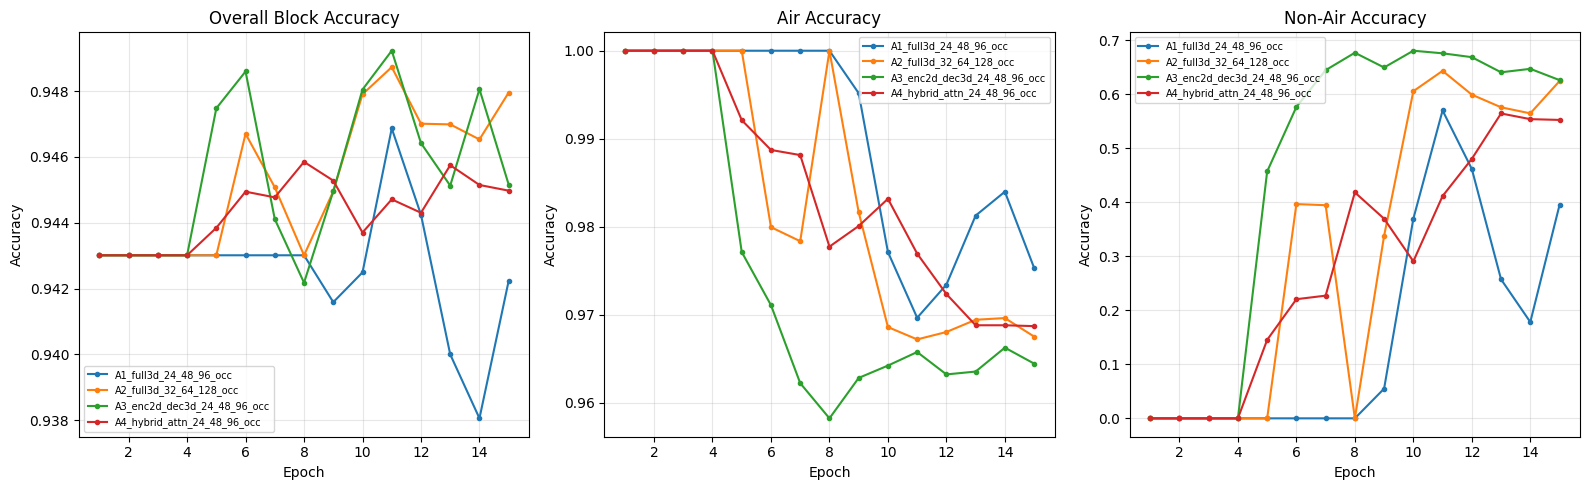

In [32]:
# ── Learning curves (best occ variant per candidate) ───────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

occ_only = summary_df[summary_df['use_occ']]
best_per_cand = occ_only.groupby('candidate').first()['model'].tolist()

for run_name in best_per_cand:
    sub = history_df[history_df['model'] == run_name]
    axes[0].plot(sub['epoch'], sub['block_acc'], label=run_name, marker='o', ms=3)
    axes[1].plot(sub['epoch'], sub['air_acc'], label=run_name, marker='o', ms=3)
    axes[2].plot(sub['epoch'], sub['nonair_acc'], label=run_name, marker='o', ms=3)

for i, title in enumerate(['Overall Block Accuracy', 'Air Accuracy', 'Non-Air Accuracy']):
    axes[i].set(title=title, xlabel='Epoch', ylabel='Accuracy')
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

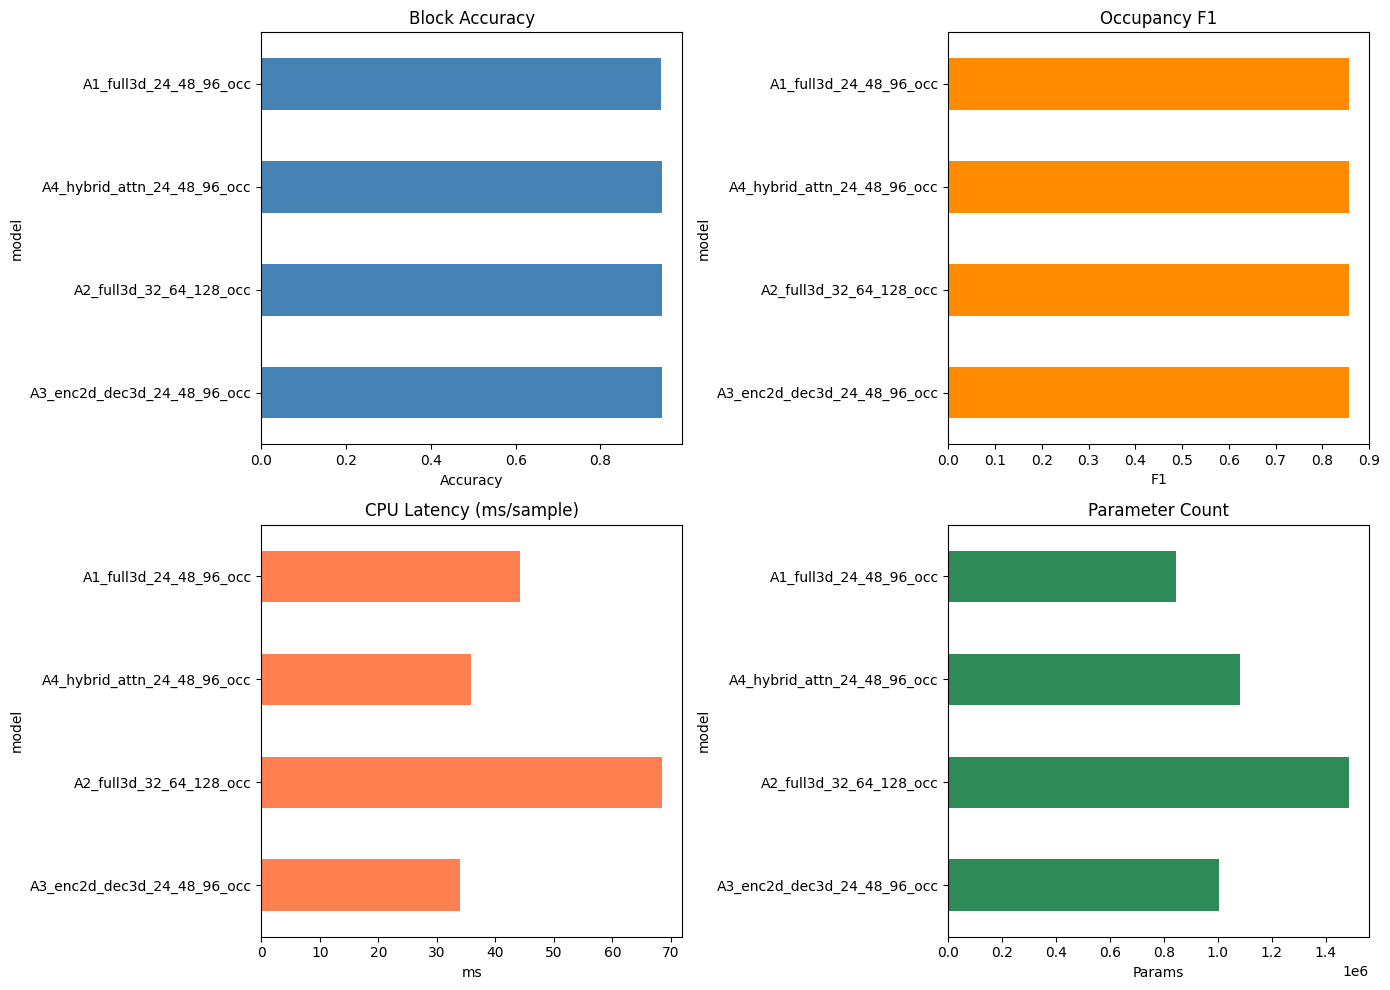

In [33]:
# ── Bar charts: accuracy, occ F1, latency, params ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

occ_df = summary_df[summary_df['use_occ']].copy().reset_index(drop=True)

occ_df.plot.barh(y='block_acc', x='model', ax=axes[0, 0], legend=False, color='steelblue')
axes[0, 0].set(title='Block Accuracy', xlabel='Accuracy')

occ_df.plot.barh(y='occ_f1', x='model', ax=axes[0, 1], legend=False, color='darkorange')
axes[0, 1].set(title='Occupancy F1', xlabel='F1')

occ_df.plot.barh(y='ms_per_sample', x='model', ax=axes[1, 0], legend=False, color='coral')
axes[1, 0].set(title='CPU Latency (ms/sample)', xlabel='ms')

occ_df.plot.barh(y='params', x='model', ax=axes[1, 1], legend=False, color='seagreen')
axes[1, 1].set(title='Parameter Count', xlabel='Params')

plt.tight_layout()
plt.show()

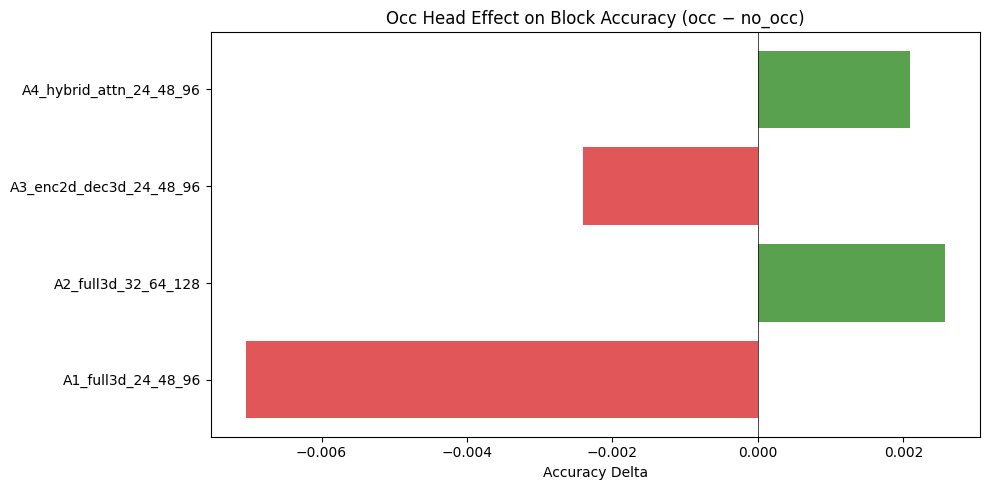

                           no_occ       occ     delta
candidate                                            
A1_full3d_24_48_96       0.949280  0.942240 -0.007039
A2_full3d_32_64_128      0.942383  0.944956  0.002574
A3_enc2d_dec3d_24_48_96  0.947561  0.945160 -0.002401
A4_hybrid_attn_24_48_96  0.942617  0.944712  0.002096


In [34]:
# ── Occ head effect on block accuracy ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
pivot = summary_df.pivot_table(index='candidate', columns='use_occ', values='block_acc')
pivot.columns = ['no_occ', 'occ']
pivot['delta'] = pivot['occ'] - pivot['no_occ']
colors = ['#e15759' if d < 0 else '#59a14f' for d in pivot['delta'].tolist()]
y_pos = np.arange(len(pivot))
ax.barh(y_pos, pivot['delta'].to_numpy(), color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(pivot.index.tolist())
ax.axvline(0, color='black', linewidth=0.5)
ax.set(title='Occ Head Effect on Block Accuracy (occ − no_occ)', xlabel='Accuracy Delta')
plt.tight_layout()
plt.show()
print(pivot)

## CPU Inference Timing

Measure per-sample latency on CPU (10 warmup, 30 measured steps).
This is the realistic deployment target for ONNX Runtime in Java.

                        model  ms_per_batch  ms_per_sample
A3_enc2d_dec3d_24_48_96_noocc     96.522593      32.174198
  A3_enc2d_dec3d_24_48_96_occ    102.730797      34.243599
  A4_hybrid_attn_24_48_96_occ    111.901130      37.300377
       A1_full3d_24_48_96_occ    136.347487      45.449162
     A1_full3d_24_48_96_noocc    143.320480      47.773493
A4_hybrid_attn_24_48_96_noocc    175.439497      58.479832
    A2_full3d_32_64_128_noocc    201.659510      67.219837
      A2_full3d_32_64_128_occ    214.979460      71.659820


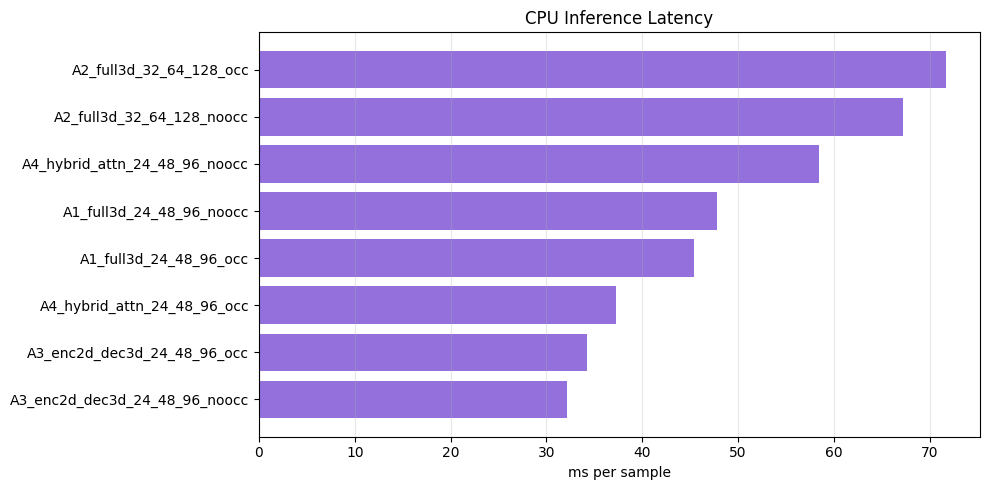

In [35]:
timing_rows = []
for run_name, model in trained_models.items():
    lat = benchmark_latency(model, val_loader, device='cpu', warmup=10, steps=30)
    timing_rows.append({'model': run_name, **lat})

timing_df = pd.DataFrame(timing_rows).sort_values('ms_per_sample')
print(timing_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(timing_df['model'], timing_df['ms_per_sample'], color='mediumpurple')
ax.set(title='CPU Inference Latency', xlabel='ms per sample')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Save Winner and Artifacts

In [36]:
winner_row = summary_df[summary_df['use_occ']].iloc[0]
winner_name = winner_row['model']
print(f'Winner: {winner_name}')
print(f'  block_acc={winner_row["block_acc"]:.4f}  air={winner_row["air_acc"]:.4f}  '
      f'nonair={winner_row["nonair_acc"]:.4f}  top5={winner_row["top5_acc"]:.4f}')
print(f'  occ_f1={winner_row["occ_f1"]:.4f}  params={winner_row["params"]:,}  '
      f'ms/sample={winner_row["ms_per_sample"]:.2f}')

save_path = ARTIFACT_DIR / f'octree_init_{winner_name}_state_dict.pt'
torch.save(trained_models[winner_name].state_dict(), save_path)
print(f'\nSaved → {save_path}')

csv_path = ARTIFACT_DIR / 'octree_init_shootout_summary.csv'
summary_df.to_csv(csv_path, index=False)
print(f'Summary → {csv_path}')

hist_path = ARTIFACT_DIR / 'octree_init_shootout_history.csv'
history_df.to_csv(hist_path, index=False)
print(f'History → {hist_path}')

Winner: A3_enc2d_dec3d_24_48_96_occ
  block_acc=0.9452  air=0.9644  nonair=0.6264  top5=0.9948
  occ_f1=0.8571  params=1,003,657  ms/sample=34.02

Saved → c:\Users\JeffHall\git\MC\VoxelTree\notebooks\experimental\artifacts\octree_init_A3_enc2d_dec3d_24_48_96_occ_state_dict.pt
Summary → c:\Users\JeffHall\git\MC\VoxelTree\notebooks\experimental\artifacts\octree_init_shootout_summary.csv
History → c:\Users\JeffHall\git\MC\VoxelTree\notebooks\experimental\artifacts\octree_init_shootout_history.csv


## Summary & Recommendations

### Key Questions Answered

1. **Is L4 effectively 2D?** Compare A3/A4 (2D-first) vs A1/A2 (all-3D). If 2D-first approaches
   match or beat all-3D, we can save compute since 2D convolutions are 32× cheaper.
2. **Does attention help at the bottleneck?** A4 vs A3 — attention at 8³ (512 tokens) is cheap
   and may capture global terrain coherence.
3. **Does the occ head help or hurt block accuracy?** Multi-task auxiliary loss can act as
   regularization or cause gradient interference.
4. **How much does wider channels help?** A1 vs A2 — diminishing returns suggest a sweet spot.

### Decision Criteria (ordered priority)

1. **block_acc** ≥ 1pp gap → winner
2. Tie: **occ_f1** (helps downstream octree pruning)
3. Tie: fewer params → winner
4. Tie: lower CPU latency → winner

### Next Steps
- Take the winning architecture to `octree_refine_shootout` as reference
- Test on real Voxy data when extraction pipeline is ready
- Profile ONNX export for Java integration

# Legacy duplicate section — do not run

The cells below are an older appended copy of this notebook kept only for reference.
Stop execution here; the updated shootout ends above at **Summary & Recommendations**.

In [37]:
raise RuntimeError(
    'Legacy duplicate section reached. Stop here and use the updated shootout cells above.'
)

RuntimeError: Legacy duplicate section reached. Stop here and use the updated shootout cells above.

## Data Loading / Synthetic Generation

Generate synthetic L4 training data. Each sample includes:
- `labels32`: target 32³ block IDs
- `heightmap32`: 5-channel height features (surface, ocean_floor, slope_x, slope_z, curvature)
- `biome32`: biome indices per (x, z) column
- `y_position`: integer Y section coordinate
- `non_empty_children`: 8-bit occupancy mask

L4 has **no parent context** — conditioning comes only from world metadata.

In [ ]:
# Legacy duplicate block removed.
pass

In [ ]:
# Legacy duplicate block removed.
pass

In [ ]:
# Legacy duplicate block removed.
pass

## Building Blocks

Shared components for all init model candidates.

In [ ]:
# Legacy duplicate block removed.
pass

## Candidate 1: Full 3D U-Net (`full3d_unet`)

Standard approach: encode conditioning into a 3D volume, then pass through
a 3-level 3D U-Net (32³→16³→8³). Decoder reconstructs 32³ block predictions.

In [ ]:
# Legacy duplicate block removed.
pass

## Candidate 2: Hybrid 2D-to-3D U-Net (`hybrid_2d_to_3d`)

Process heightmap and biome with a 2D conv encoder first, then expand the
2D features to 3D and let the 3D decoder refine them with skip connections.

In [ ]:
# Legacy duplicate block removed.
pass

## Candidate 3: Pure 2D Then 3D (`pure2d_then_3d`)

Deep 2D encoder all the way down to 4² feature map, then learned 3D
expansion via ConvTranspose3d (4³→8³→16³→32³).

In [ ]:
# Legacy duplicate block removed.
pass

## Training Infrastructure

In [ ]:
# Legacy duplicate block removed.
pass

## Shootout Runner

Sweep 3 architectures × 3 channel widths × with/without occ head = **18 configurations**.
Each trains for 15 epochs.

In [ ]:
# Legacy duplicate block removed.
pass

## Results Summary

In [ ]:
# Legacy duplicate block removed.
pass

In [ ]:
# Legacy duplicate block removed.
pass

In [ ]:
# Legacy duplicate block removed.
pass

In [ ]:
# Legacy duplicate block removed.
pass

## Save Winner and Artifacts

In [ ]:
# Legacy duplicate block removed.
pass

## Summary & Recommendations

### Key Questions Answered

- **Best 2D→3D strategy for L4?** Compare 3D-native, hybrid, and pure-2D approaches.
  - 3D-native treats everything as volume from the start.
  - Hybrid leverages 2D structure of heightmap/biome before 3D decoding.
  - Pure-2D is most parameter-efficient but may lack spatial flexibility.
- **Does the occupancy head help block accuracy?** Or does it hurt via gradient interference?
- **What's the compute budget?** L4 runs once per WorldSection, so latency is less critical.

### Decision Criteria (ordered priority)

1. **block_acc** ≥ 1pp gap → winner
2. Tie: **occ_f1** (helps downstream pruning)
3. Tie: fewer params → winner
4. Tie: lower latency → winner

### Next Steps
- Take the winning architecture to the refine notebook as the parent model
- Test on real Voxy data when available
- Profile ONNX export for Java integration

# Octree Init (L4) — Architecture Shootout

This notebook tests candidate architectures for **Model A (`octree_init`)**, the root-level model
that predicts a 32³ WorldSection from heightmap + biome + y_position alone (no parent context).

## What we're testing

L4 is the coarsest LOD level (16m/voxel, covering 512³ blocks). Since the terrain at this scale
is effectively 2D — the interesting variation is height-wise, not volumetric — we test:

| ID | Architecture | Rationale |
|----|-------------|----------|
| `full_3d_unet` | Standard 3D U-Net (32³→16³→8³) | Baseline — treats L4 as a full 3D problem |
| `hybrid_2d_to_3d` | 2D conv encoder → expand to 3D decoder | Exploits the 2D nature of conditioning |
| `pure_2d_then_3d` | 2D initial stages, 3D for 8³→16³→32³ decoder | Hybrid compromise |

For each architecture we sweep channel widths: `[16,32,64]`, `[24,48,96]`, `[32,64,128]`
and test with/without the occupancy prediction head.

## Metrics
- Block accuracy (overall + air-only)
- Occupancy F1 (precision, recall per bit)
- Inference latency (CPU)
- Parameter count

In [ ]:
# Legacy duplicate block removed.
pass

## Data Loading / Synthetic Generation

The octree training data pipeline may not exist yet, so we generate **plausible synthetic data**
as default, with a flag to load real data if available.

Synthetic generation strategy:
- Surface height drawn from smooth Perlin-ish noise (sine superposition)
- Blocks below surface: stone/dirt/grass layers; above surface: air
- Biomes: spatially coherent random patches
- `non_empty_children`: derived from block content (any non-air → bit set)

In [ ]:
# Legacy duplicate block removed.
pass

In [ ]:
# Legacy duplicate block removed.
pass

## Dataset & DataLoader

In [ ]:
# Legacy duplicate block removed.
pass

## Building Blocks

Shared components used across all candidate architectures:
- `Conv3dBlock`: Conv3d + BatchNorm + ReLU
- `DoubleConv3d`: Two consecutive Conv3dBlocks
- `OccupancyHead`: GAP → MLP → 8-way binary predictions
- `ConditioningEncoder`: Embeds heightmap + biome + y_position into input channels

In [ ]:
# Legacy duplicate block removed.
pass

## Candidate 1: Full 3D U-Net (`full_3d_unet`)

Standard 3D U-Net architecture: all conditioning is embedded as input channels to the
first encoder level. Three encoder levels (32³→16³→8³), bottleneck at 8³, symmetric decoder
with skip connections.

In [ ]:
# Legacy duplicate block removed.
pass

## Candidate 2: Hybrid 2D→3D (`hybrid_2d_to_3d`)

Exploits the observation that L4 conditioning is fundamentally 2D (heightmap + biome are 2D).
Uses a 2D conv encoder to extract spatial features, then expands to 3D for the decoder path.

Architecture:
- 2D encoder: 32² → 16² → 8² (standard 2D convolutions on heightmap+biome)
- Expand to 3D at each level by repeating/broadcasting along Y
- 3D decoder: 8³ → 16³ → 32³ with skip connections from expanded 2D features

In [ ]:
# Legacy duplicate block removed.
pass

## Candidate 3: Pure 2D then 3D (`pure_2d_then_3d`)

A more aggressive hybrid: 2D processing all the way to a compact latent,
then a learned 3D expansion using ConvTranspose3d. Only the deep decoder
operates in true 3D. This tests whether L4 terrain is really easier to
learn as a 2D-first problem.

In [ ]:
# Legacy duplicate block removed.
pass

## Training Infrastructure

Shared training loop, evaluation, and latency benchmarking for all candidates.

**Loss:**
- Block classification: `CrossEntropyLoss` on `[B×32³, num_classes]` vs `[B×32³]`
- Occupancy: `BCEWithLogitsLoss` on `[B, 8]` vs ground truth bits
- Combined: `block_loss + 0.5 * occ_loss`

In [ ]:
# Legacy duplicate block removed.
pass

## Shootout Runner

Sweep all 3 architectures × 3 channel widths × with/without occ head = **18 configurations**.
Each trains for 15 epochs (short runs for rapid iteration).

In [ ]:
# Legacy duplicate block removed.
pass

## Results Summary

In [ ]:
# Legacy duplicate block removed.
pass

In [ ]:
# Legacy duplicate block removed.
pass

In [ ]:
# Legacy duplicate block removed.
pass

In [ ]:
# Legacy duplicate block removed.
pass

## Inference Timing (CPU)

Measure per-sample inference latency on CPU for all candidates.
This is the realistic deployment target since ONNX Runtime in Java runs on CPU.

In [ ]:
# Legacy duplicate block removed.
pass

## Save Winner and Artifacts

In [ ]:
# Legacy duplicate block removed.
pass

## Summary & Recommendations

### Decision Criteria (ordered priority)

1. **block_acc** gap ≥ 1pp → take the winner
2. Tie: prefer the architecture with better **nonair_acc** (non-air blocks are harder)
3. Still tied: prefer fewer parameters
4. Still tied: prefer lower CPU latency

### Key Questions Answered

- **Is L4 effectively 2D?** Compare `hybrid_2d_to_3d` vs `full_3d_unet`. If hybrid wins, we can save compute.
- **Does the occ head hurt block accuracy?** Compare with/without — multitask auxiliary loss sometimes helps.
- **How much do wider channels help?** Diminishing returns suggest a sweet spot.

### Next Steps
- Take the winning architecture to the `octree_refine_shootout` notebook to test parent context injection
- Validate on real Voxy data once the extraction pipeline is ready
- Export the winner to ONNX and test in Java

# Octree Init (L4) — Architecture Shootout

This notebook tests candidate architectures for **Model A (`octree_init`)**, the root-level model that predicts a 32³ WorldSection from heightmap + biome + y_position alone (no parent context).

## What we're testing

L4 is the coarsest LOD level (16m/voxel, covering 512³ blocks). Since the terrain at this scale is effectively 2D — the interesting variation is height-wise, not volumetric — we test:

| ID | Architecture | Rationale |
|----|-------------|-----------|
| `full_3d_unet` | Standard 3D U-Net | Baseline — treats L4 as a full 3D problem |
| `hybrid_2d_to_3d` | 2D encoder → 3D decoder | Exploits the 2D nature of conditioning at L4 |
| `pure_3d_unet_small` | 3D U-Net with smaller channels | Test if smaller is enough for the coarse task |

For each architecture, we sweep channel widths: `[16,32,64]`, `[24,48,96]`, `[32,64,128]`
and test with/without the occupancy prediction head.

## Metrics
- Block accuracy (overall + air-only)
- Occupancy F1 (precision, recall per bit)
- Inference latency (CPU)
- Parameter count